In [1]:
from train_network import Classifier

In [2]:
clf = Classifier('/mnt/f/Code/Music_Dataset/fma_small/fma_small/', '/mnt/f/Code/Music_Dataset/fma_metadata/fma_metadata/tracks.csv')
clf.generate_batch()

Lengths:  305 76


In [3]:
clf.train_model('/mnt/f/Code/Thesis/model.h5')

Now in training model


In [4]:
clf.predict()

Mel spectrogram is:  [[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 8.14090110e-03 ... 9.54017868e+01
  7.28407669e+01 3.91414108e+01]
 [0.00000000e+00 0.00000000e+00 2.16620066e-03 ... 2.53853264e+01
  1.93820953e+01 1.04150829e+01]
 ...
 [0.00000000e+00 0.00000000e+00 2.36588662e-07 ... 1.40376787e-05
  2.98213223e-07 1.10330453e-04]
 [0.00000000e+00 0.00000000e+00 1.95993666e-10 ... 1.45595780e-09
  1.27395894e-09 1.11671085e-04]
 [0.00000000e+00 0.00000000e+00 2.64286631e-11 ... 9.28241428e-10
  9.74529568e-10 1.14041657e-04]]
Image shape is:  (128, 128, 3)
Mel spectrogram is:  [[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 8.14090110e-03 ... 9.54017868e+01
  7.28407669e+01 3.91414108e+01]
 [0.00000000e+00 0.00000000e+00 2.16620066e-03 ... 2.53853264e+01
  1.93820953e+01 1.04150829e+01]
 ...
 [0.00000000e+00 0.000000

In [1]:
import os
import random
import glob
import shutil

all_files = []
for root, dirs, files in os.walk('/mnt/f/Code/Music_Dataset/Spectrograms/'):
    if len(dirs) == 0:
#         currrent_class = root.split('/')[-1]
#         dest = f'/mnt/f/Code/Music_Dataset/Spectrograms/{current_class}/'
        for f in files:
            all_files.append(root + '/' + f)

for i in range(20):
    to_be_moved = random.sample(all_files, 50)
    s1 = set(all_files)
    s2 = set(to_be_moved)
    all_files = list(s1 - s2)
    dest = f'/mnt/f/Code/Music_Dataset/Spectrograms/random500_{i}'
    os.makedirs(dest)
    for f in to_be_moved:
        shutil.move(f, dest)
        
os.makedirs('/mnt/f/Code/Music_Dataset/Spectrograms/random_discovery/')
move_1 = random.sample(all_files, 50)
for f in move_1:
    shutil.move(f, '/mnt/f/Code/Music_Dataset/Spectrograms/random_discovery/')
    

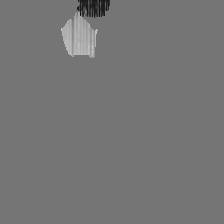

In [24]:
from PIL import Image, ImageOps
import numpy as np
import math
img1 = np.asarray(Image.open('/mnt/f/Code/Music_Dataset/sixth_concepts/concepts_Rock/concepts/layer4.2.conv2_Rock_concept1_patches/002_22.png').convert('L'))
img2 = np.asarray(Image.open('/mnt/f/Code/Music_Dataset/sixth_concepts/concepts_Rock/concepts/layer4.2.conv2_Rock_concept1_patches/001_41.png').convert('L'))

res = np.full(img1.shape, 117)

for i in range(0, len(img1)):
    for j in range(0, len(img1[0])):
        img1_pixel = abs(img1[i,j] - 117)
        img2_pixel = abs(img2[i,j] - 117)
        if img1_pixel > img2_pixel and img1_pixel > 10:
            res[i][j] = img1[i,j]
        elif img2_pixel > img1_pixel and img2_pixel > 10:
            res[i][j] = img2[i][j]
        else:
            res[i][j] = 117

# print('Output: ', res)
output = Image.fromarray(np.uint8(res), 'L')
output.show()